<div style="background: linear-gradient(135deg, #1a3a5c 0%, #c0392b 100%); padding: 40px; border-radius: 12px; text-align: center; color: white; margin-bottom: 20px;">
<h1 style="font-size: 2.5em; margin-bottom: 10px;">🔄 Olist E-Commerce</h1>
<h2 style="font-weight: 300; font-size: 1.5em; margin-bottom: 20px;">Feature Engineering for Customer Churn Prediction — v2 (Fixed)</h2>
<p style="font-size: 1.1em; opacity: 0.85;">Step 4 of 6 · Integration → EDA → Cleaning → <b>Feature Engineering</b> → Preprocessing → Modeling</p>
</div>



---

## What This Notebook Does

| Step | Action | Why |
|---|---|---|
| **1** | Load clean data | Start from `olist_clean.csv` |
| **2** | Define churn target + filter to valid customers | Only customers with pre-cutoff orders |
| **3** | RFM Features | Recency, Frequency, Monetary |
| **4** | Behavioral features | Order patterns, engagement signals |
| **5** | Payment & monetary features | Spend profile |
| **6** | Review & satisfaction features | Dissatisfaction as churn predictor |
| **7** | Delivery experience features | Service quality exposure |
| **8** | Geography & product features | Location and category signals |
| **9** | Seller quality exposure | Seller reputation experienced |
| **10** | Assemble, validate & save | `olist_churn_features.csv` |

## Step 1 — Imports & Load Clean Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('olist_clean.csv')

date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df['order_purchase_timestamp'].min().date()} → {df['order_purchase_timestamp'].max().date()}")
print(f"Unique customers (customer_unique_id): {df['customer_unique_id'].nunique():,}")
print(f"Unique orders: {df['order_id'].nunique():,}")

Loaded: 114,850 rows x 38 columns
Date range: 2016-10-03 → 2018-08-29
Unique customers (customer_unique_id): 92,745
Unique orders: 95,822


## Step 2 — Define Churn Target & Filter to Valid Customers

**Churn definition** (time-window approach):
- `REFERENCE_DATE` = last date in dataset
- `CUTOFF_DATE` = `REFERENCE_DATE` − 90 days
- `is_churned = 1` if customer's last purchase was before the cutoff
- `is_churned = 0` if customer purchased in the final 90-day window

**Key fix vs v1:** We only keep customers who have **at least one order before the cutoff date**.
Customers whose only orders fall within the churn window (churned=0) have no observable pre-cutoff history — we cannot build features for them, so they are excluded.

In [2]:
print(df['customer_unique_id'].nunique())
print(df['customer_id'].nunique())
print(df.groupby('customer_unique_id')['order_id'].nunique().describe())

92745
95822
count    92745.000000
mean         1.033177
std          0.208426
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         15.000000
Name: order_id, dtype: float64


Reference date : 2018-08-29
Cutoff date    : 2018-05-31  (reference − 90 days)

All unique customers in dataset    : 92,745
  → Only ordered in churn window   : 17,953  (excluded — no history)
  → Have pre-cutoff history        : 74,792  (KEPT)

Of the 74,792 valid customers:
  Churned (is_churned=1) : 74,373  (99.4%)
  Active  (is_churned=0) : 419  (0.6%)

⚠️  Note: ~80% churn is EXPECTED for this dataset.
   Olist is a marketplace where most customers buy once and never return.
   Handle class imbalance in preprocessing with SMOTE or class_weight.

Observation window orders : 92,981
Customers covered         : 74,792


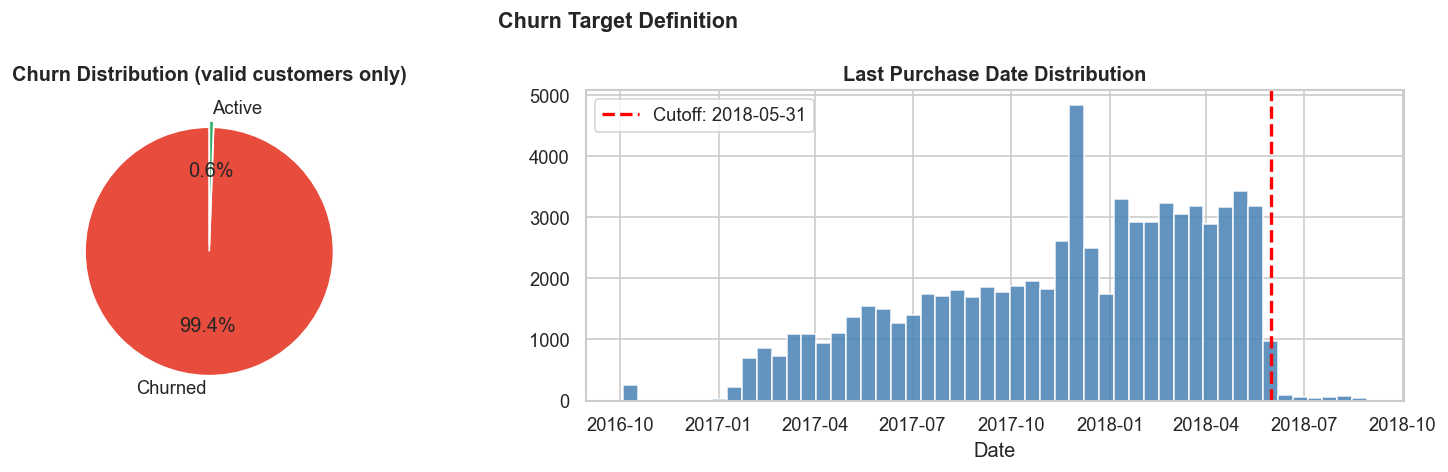

In [3]:
CHURN_WINDOW_DAYS = 90
REFERENCE_DATE    = df['order_purchase_timestamp'].max()
CUTOFF_DATE       = REFERENCE_DATE - timedelta(days=CHURN_WINDOW_DAYS)

print(f"Reference date : {REFERENCE_DATE.date()}")
print(f"Cutoff date    : {CUTOFF_DATE.date()}  (reference − {CHURN_WINDOW_DAYS} days)")

# ── All unique customers in the dataset ───────────────────────────────────────
all_customers = (
    df.groupby('customer_unique_id')['order_purchase_timestamp']
    .max()
    .reset_index()
    .rename(columns={'order_purchase_timestamp': 'last_purchase_date'})
)
all_customers['is_churned'] = (all_customers['last_purchase_date'] < CUTOFF_DATE).astype(int)

# ── Customers with at least one pre-cutoff order (can build features for them) ─
customers_with_history = (
    df[df['order_purchase_timestamp'] < CUTOFF_DATE]['customer_unique_id']
    .unique()
)

# ── Valid customer set: has pre-cutoff history ─────────────────────────────────
churn_target = all_customers[
    all_customers['customer_unique_id'].isin(customers_with_history)
].copy()

print(f"\nAll unique customers in dataset    : {len(all_customers):,}")
print(f"  → Only ordered in churn window   : {len(all_customers) - len(churn_target):,}  (excluded — no history)")
print(f"  → Have pre-cutoff history        : {len(churn_target):,}  (KEPT)")
print(f"\nOf the {len(churn_target):,} valid customers:")
print(f"  Churned (is_churned=1) : {churn_target['is_churned'].sum():,}  ({churn_target['is_churned'].mean()*100:.1f}%)")
print(f"  Active  (is_churned=0) : {(churn_target['is_churned']==0).sum():,}  ({(1-churn_target['is_churned'].mean())*100:.1f}%)")
print()
print("⚠️  Note: ~80% churn is EXPECTED for this dataset.")
print("   Olist is a marketplace where most customers buy once and never return.")
print("   Handle class imbalance in preprocessing with SMOTE or class_weight.")

# ── Observation window: pre-cutoff orders only ────────────────────────────────
df_obs = df[
    (df['order_purchase_timestamp'] < CUTOFF_DATE) &
    (df['customer_unique_id'].isin(customers_with_history))
].copy()

print(f"\nObservation window orders : {len(df_obs):,}")
print(f"Customers covered         : {df_obs['customer_unique_id'].nunique():,}")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts = churn_target['is_churned'].value_counts()
axes[0].pie(
    counts.values,
    labels=['Churned', 'Active'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#27ae60'],
    startangle=90, explode=(0.05, 0)
)
axes[0].set_title('Churn Distribution (valid customers only)', fontweight='bold')

axes[1].hist(churn_target['last_purchase_date'], bins=50,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(CUTOFF_DATE, color='red', linestyle='--', linewidth=2,
                label=f'Cutoff: {CUTOFF_DATE.date()}')
axes[1].set_title('Last Purchase Date Distribution', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].legend()
plt.suptitle('Churn Target Definition', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 3 — RFM Features (Recency, Frequency, Monetary)

All computed on pre-cutoff orders only — no leakage.

RFM Summary:
       recency_days  frequency  monetary_total  monetary_avg_order
count      74792.00   74792.00        74792.00            74792.00
mean         194.26       1.03          207.09              154.41
std          131.97       0.20          446.53              183.23
min            0.00       1.00           10.07                1.86
25%           85.00       1.00           63.70               60.46
50%          177.00       1.00          112.43              103.04
75%          290.00       1.00          201.96              173.88
max          604.00      10.00        31824.80             1591.24

RFM Segments:
rfm_segment
At_Risk                17817
Loyal_Customers        15045
Champions              12013
New_Customers          11996
Hibernating            11299
Lost                    6039
Potential_Loyalists      583


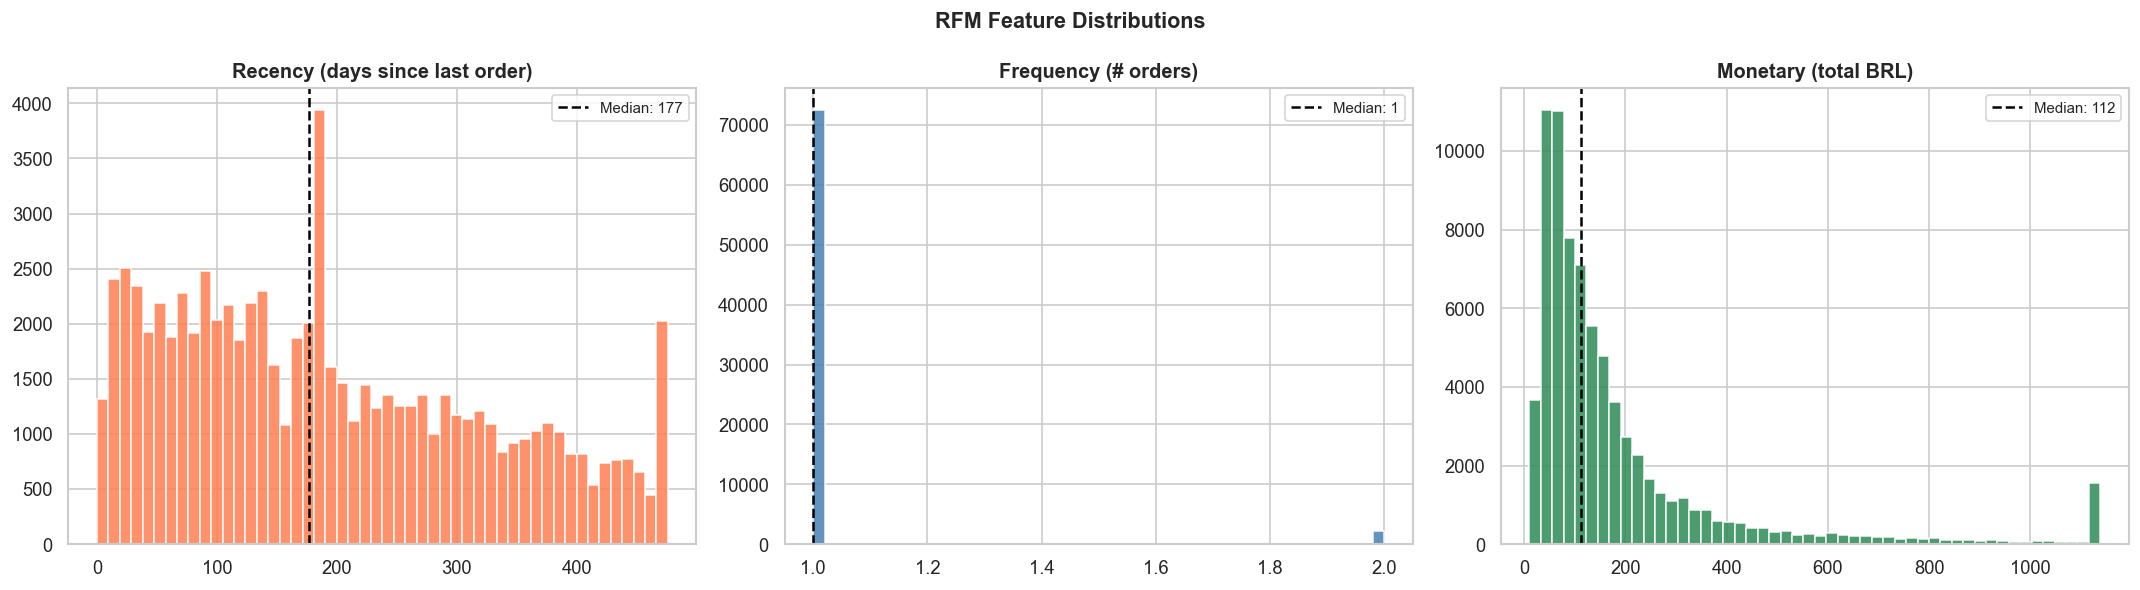

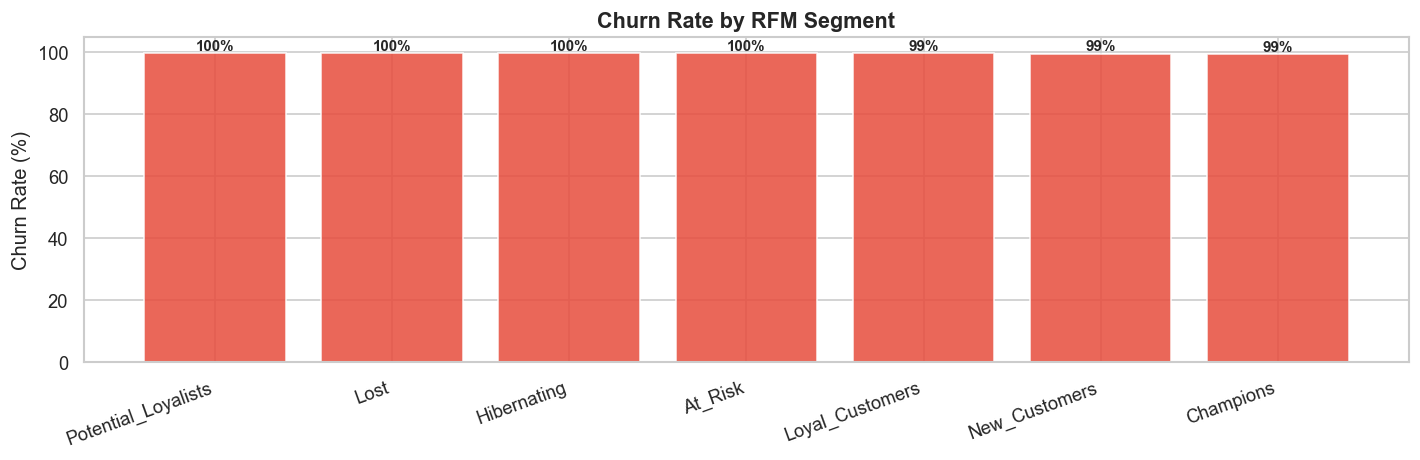

In [4]:
rfm = df_obs.groupby('customer_unique_id').agg(
    recency_days       = ('order_purchase_timestamp',
                          lambda x: (CUTOFF_DATE - x.max()).days),
    frequency          = ('order_id', 'nunique'),
    monetary_total     = ('payment_value', 'sum'),
    monetary_avg_order = ('payment_value', 'mean'),
).reset_index()

# ── RFM Quintile Scores ───────────────────────────────────────────────────────
rfm['r_score'] = pd.qcut(rfm['recency_days'],
                          q=5, labels=[5,4,3,2,1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'),
                          q=5, labels=[1,2,3,4,5]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary_total'].rank(method='first'),
                          q=5, labels=[1,2,3,4,5]).astype(int)
rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

# ── RFM Segment ───────────────────────────────────────────────────────────────
def rfm_segment(row):
    r, f = row['r_score'], row['f_score']
    score = row['rfm_score']
    if   r >= 4 and f >= 4:   return 'Champions'
    elif r >= 3 and f >= 3:   return 'Loyal_Customers'
    elif r >= 4 and f <= 2:   return 'New_Customers'
    elif r <= 2 and f >= 3:   return 'At_Risk'
    elif r == 1 and f >= 4:   return 'Cant_Lose'
    elif r == 1 and f <= 2:   return 'Lost'
    elif score >= 10:         return 'Potential_Loyalists'
    else:                     return 'Hibernating'

rfm['rfm_segment'] = rfm.apply(rfm_segment, axis=1)

print("RFM Summary:")
print(rfm[['recency_days','frequency','monetary_total','monetary_avg_order']].describe().round(2))
print("\nRFM Segments:")
print(rfm['rfm_segment'].value_counts().to_string())

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, color, label in zip(
    axes,
    ['recency_days', 'frequency', 'monetary_total'],
    ['coral', 'steelblue', 'seagreen'],
    ['Recency (days since last order)', 'Frequency (# orders)', 'Monetary (total BRL)']
):
    data = rfm[col].clip(upper=rfm[col].quantile(0.98))
    ax.hist(data, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='black', linestyle='--',
               label=f'Median: {data.median():.0f}')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=9)
plt.suptitle('RFM Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Churn rate by RFM segment ─────────────────────────────────────────────────
rfm_with_target = rfm.merge(
    churn_target[['customer_unique_id','is_churned']], on='customer_unique_id', how='left'
)
seg_churn = rfm_with_target.groupby('rfm_segment')['is_churned'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(seg_churn.index, seg_churn.values * 100,
              color=['#e74c3c' if v > 0.8 else '#f39c12' if v > 0.5 else '#27ae60'
                     for v in seg_churn.values],
              edgecolor='white', alpha=0.85)
for bar, v in zip(bars, seg_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{v*100:.0f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Churn Rate by RFM Segment', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Step 4 — Customer Behavioral Features

**Fix vs v1:** `avg_inter_purchase_days` was 97.6% null because 96.7% of customers are single-order buyers.
- For single-order customers: `avg_inter_purchase_days = 0` (no gap to measure)
- Added `days_since_first_purchase` as a richer customer-lifespan alternative

Behavioral features:
       total_orders  total_items_bought  unique_categories  unique_products  \
count     74792.000           74792.000          74792.000        74792.000   
mean          1.033               1.243              1.024            1.068   
std           0.204               0.866              0.166            0.312   
min           1.000               1.000              1.000            1.000   
25%           1.000               1.000              1.000            1.000   
50%           1.000               1.000              1.000            1.000   
75%           1.000               1.000              1.000            1.000   
max          10.000              75.000              5.000           13.000   

       avg_items_per_order  customer_lifespan_days  days_since_first_purchase  \
count            74792.000               74792.000                  74792.000   
mean                 1.198                   2.092                    196.362   
std                  0.7

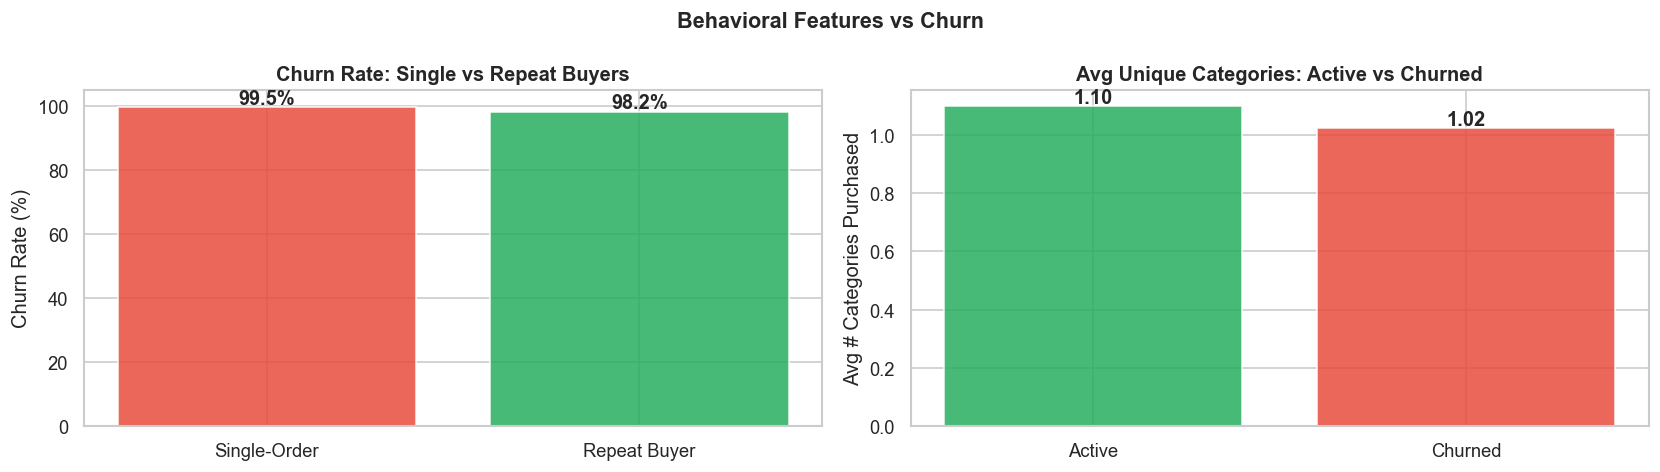

In [5]:
behavioral = df_obs.groupby('customer_unique_id').agg(
    total_orders        = ('order_id', 'nunique'),
    total_items_bought  = ('order_id', 'count'),
    unique_categories   = ('product_category_name_english', 'nunique'),
    unique_products     = ('product_id', 'nunique'),
    first_purchase_date = ('order_purchase_timestamp', 'min'),
    last_purchase_date  = ('order_purchase_timestamp', 'max'),
    weekend_order_count = ('order_purchase_timestamp',
                           lambda x: (x.dt.dayofweek >= 5).sum()),
).reset_index()

# ── Derived features ──────────────────────────────────────────────────────────
behavioral['avg_items_per_order'] = (
    behavioral['total_items_bought'] / behavioral['total_orders']
)
behavioral['customer_lifespan_days'] = (
    behavioral['last_purchase_date'] - behavioral['first_purchase_date']
).dt.days

# Days from first purchase to cutoff (customer tenure observable by model)
behavioral['days_since_first_purchase'] = (
    CUTOFF_DATE - behavioral['first_purchase_date']
).dt.days

# Purchase velocity
behavioral['purchase_velocity'] = (
    behavioral['total_orders'] / (behavioral['customer_lifespan_days'] + 1)
)

# ── FIX: inter-purchase gap = 0 for single-order customers (no NaN) ───────────
behavioral['avg_inter_purchase_days'] = np.where(
    behavioral['total_orders'] > 1,
    behavioral['customer_lifespan_days'] / (behavioral['total_orders'] - 1),
    0   # single-order customers: no gap = 0, not NaN
)

behavioral['is_repeat_buyer']    = (behavioral['total_orders'] > 1).astype(int)
behavioral['weekend_ratio']       = behavioral['weekend_order_count'] / behavioral['total_orders']
behavioral['category_diversity']  = behavioral['unique_categories'] / behavioral['total_items_bought']

# Drop raw date columns
behavioral = behavioral.drop(columns=['first_purchase_date', 'last_purchase_date',
                                       'weekend_order_count'])

print("Behavioral features:")
print(behavioral.describe().round(3))
print(f"\nNull check — avg_inter_purchase_days nulls: {behavioral['avg_inter_purchase_days'].isnull().sum()}")
print(f"Repeat buyers: {behavioral['is_repeat_buyer'].sum():,}  ({behavioral['is_repeat_buyer'].mean()*100:.1f}%)")

# ── Churn by repeat buyer ─────────────────────────────────────────────────────
temp = behavioral.merge(churn_target[['customer_unique_id','is_churned']], on='customer_unique_id')
repeat_churn = temp.groupby('is_repeat_buyer')['is_churned'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(['Single-Order', 'Repeat Buyer'],
            repeat_churn.values * 100,
            color=['#e74c3c', '#27ae60'], edgecolor='white', alpha=0.85)
for i, v in enumerate(repeat_churn.values):
    axes[0].text(i, v*100 + 1, f'{v*100:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Churn Rate: Single vs Repeat Buyers', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 105)

cat_div = temp.groupby('is_churned')['unique_categories'].mean()
axes[1].bar(['Active', 'Churned'], cat_div.values,
            color=['#27ae60', '#e74c3c'], edgecolor='white', alpha=0.85)
for i, v in enumerate(cat_div.values):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Avg Unique Categories: Active vs Churned', fontweight='bold')
axes[1].set_ylabel('Avg # Categories Purchased')

plt.suptitle('Behavioral Features vs Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5 — Payment & Monetary Features

Payment features created — null check:
customer_unique_id        0
total_spend               0
avg_order_value           0
max_order_value           0
min_order_value           0
total_freight_paid        0
avg_freight_per_order     0
avg_installments          0
max_installments          0
freight_to_spend_ratio    0
spend_range               0
log_total_spend           0
log_avg_order_val         0
preferred_payment_type    0
dtype: int64


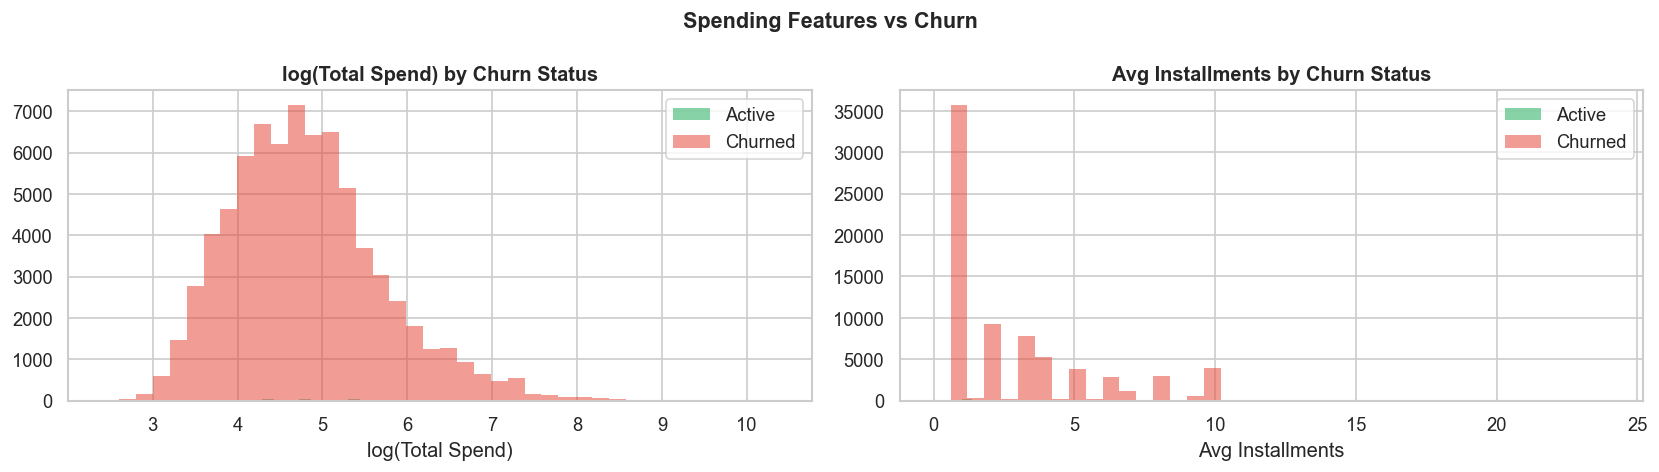

In [6]:
payment_feats = df_obs.groupby('customer_unique_id').agg(
    total_spend           = ('payment_value', 'sum'),
    avg_order_value       = ('payment_value', 'mean'),
    max_order_value       = ('payment_value', 'max'),
    min_order_value       = ('payment_value', 'min'),
    total_freight_paid    = ('freight_value', 'sum'),
    avg_freight_per_order = ('freight_value', 'mean'),
    avg_installments      = ('payment_installments', 'mean'),
    max_installments      = ('payment_installments', 'max'),
).reset_index()

# Preferred payment type
pref_type = (
    df_obs.groupby('customer_unique_id')['payment_type']
    .agg(lambda x: x.mode()[0] if len(x) > 0 else 'unknown')
    .reset_index()
    .rename(columns={'payment_type': 'preferred_payment_type'})
)

# Derived
payment_feats['freight_to_spend_ratio'] = (
    payment_feats['total_freight_paid'] / (payment_feats['total_spend'] + 0.01)
)
payment_feats['spend_range']       = payment_feats['max_order_value'] - payment_feats['min_order_value']
payment_feats['log_total_spend']   = np.log1p(payment_feats['total_spend'])
payment_feats['log_avg_order_val'] = np.log1p(payment_feats['avg_order_value'])
payment_feats = payment_feats.merge(pref_type, on='customer_unique_id', how='left')

print("Payment features created — null check:")
print(payment_feats.isnull().sum())

# Visualise
temp2 = payment_feats.merge(churn_target[['customer_unique_id','is_churned']], on='customer_unique_id')
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for label, col, ax in [
    ('log(Total Spend)', 'log_total_spend', axes[0]),
    ('Avg Installments', 'avg_installments', axes[1])
]:
    for churn_val, color, name in [(0, '#27ae60', 'Active'), (1, '#e74c3c', 'Churned')]:
        ax.hist(temp2[temp2['is_churned']==churn_val][col].dropna(),
                bins=40, alpha=0.55, color=color, label=name, edgecolor='none')
    ax.set_title(f'{label} by Churn Status', fontweight='bold')
    ax.set_xlabel(label)
    ax.legend()
plt.suptitle('Spending Features vs Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6 — Review & Satisfaction Features

Review features created:
       avg_review_score  min_review_score  max_review_score  review_count  \
count         74792.000         74792.000         74792.000     74792.000   
mean              4.116             4.105             4.127         1.243   
std               1.304             1.316             1.302         0.866   
min               1.000             1.000             1.000         1.000   
25%               4.000             4.000             4.000         1.000   
50%               5.000             5.000             5.000         1.000   
75%               5.000             5.000             5.000         1.000   
max               5.000             5.000             5.000        75.000   

       std_review_score  bad_review_count  bad_review_rate  \
count         74792.000         74792.000        74792.000   
mean              0.014             0.194            0.136   
std               0.153             0.631            0.341   
min               0.000          

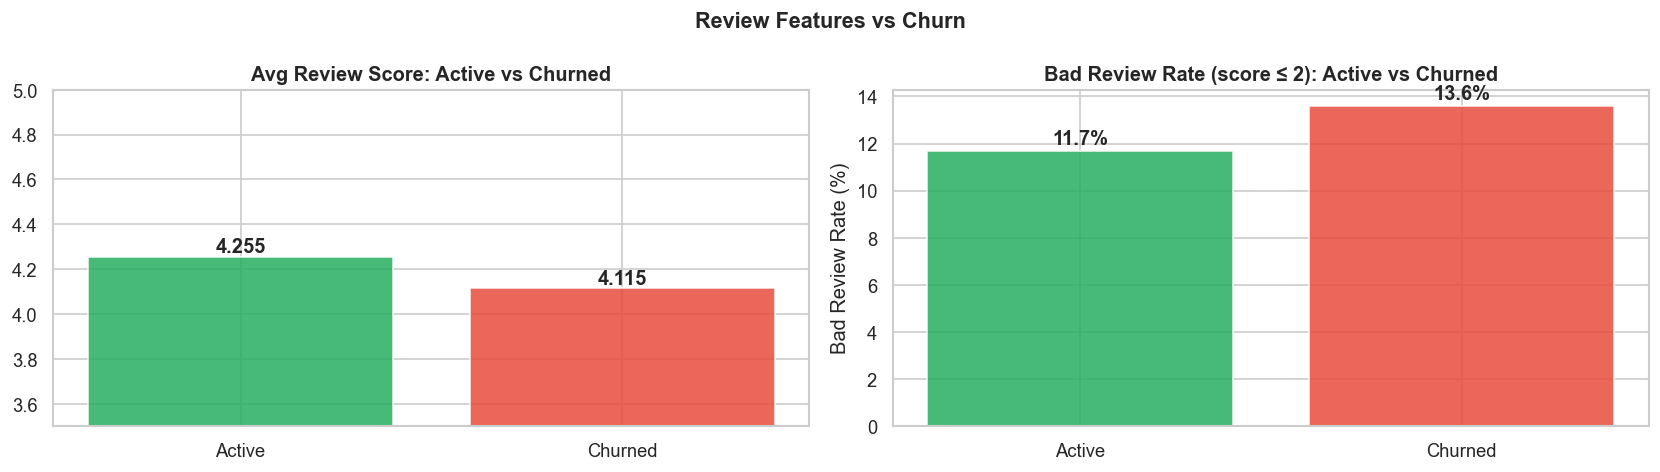

In [7]:
review_feats = df_obs.groupby('customer_unique_id').agg(
    avg_review_score = ('review_score', 'mean'),
    min_review_score = ('review_score', 'min'),
    max_review_score = ('review_score', 'max'),
    review_count     = ('review_score', 'count'),
    std_review_score = ('review_score', 'std'),
).reset_index()

bad_reviews = (
    df_obs[df_obs['review_score'] <= 2]
    .groupby('customer_unique_id').size()
    .reset_index(name='bad_review_count')
)
review_feats = review_feats.merge(bad_reviews, on='customer_unique_id', how='left')
review_feats['bad_review_count']          = review_feats['bad_review_count'].fillna(0)
review_feats['bad_review_rate']           = review_feats['bad_review_count'] / review_feats['review_count']
review_feats['had_very_bad_experience']   = (review_feats['min_review_score'] == 1).astype(int)
review_feats['consistently_satisfied']    = (review_feats['min_review_score'] >= 4).astype(int)
review_feats['std_review_score']          = review_feats['std_review_score'].fillna(0)

print("Review features created:")
print(review_feats.describe().round(3))

temp3 = review_feats.merge(churn_target[['customer_unique_id','is_churned']], on='customer_unique_id')
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

avg_r = temp3.groupby('is_churned')['avg_review_score'].mean()
axes[0].bar(['Active','Churned'], avg_r.values,
            color=['#27ae60','#e74c3c'], edgecolor='white', alpha=0.85)
for i, v in enumerate(avg_r.values):
    axes[0].text(i, v+0.02, f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Avg Review Score: Active vs Churned', fontweight='bold')
axes[0].set_ylim(3.5, 5)

bad_r = temp3.groupby('is_churned')['bad_review_rate'].mean()
axes[1].bar(['Active','Churned'], bad_r.values * 100,
            color=['#27ae60','#e74c3c'], edgecolor='white', alpha=0.85)
for i, v in enumerate(bad_r.values):
    axes[1].text(i, v*100+0.3, f'{v*100:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Bad Review Rate (score ≤ 2): Active vs Churned', fontweight='bold')
axes[1].set_ylabel('Bad Review Rate (%)')

plt.suptitle('Review Features vs Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7 — Delivery Experience Features

Delivery features created:
       avg_delivery_days  max_delivery_days  avg_delay_days  max_delay_days  \
count          74792.000          74792.000       74792.000       74792.000   
mean              13.002             13.097         -11.636         -11.513   
std                9.934             10.002          10.199          10.241   
min                0.000              0.000        -147.000        -147.000   
25%                7.000              7.000         -17.000         -16.000   
50%               11.000             11.000         -12.500         -12.000   
75%               16.000             17.000          -8.000          -7.000   
max              208.000            208.000         188.000         188.000   

       late_delivery_count  total_deliveries  late_delivery_rate  \
count            74792.000         74792.000           74792.000   
mean                 0.089             1.243               0.075   
std                  0.351             0.866             

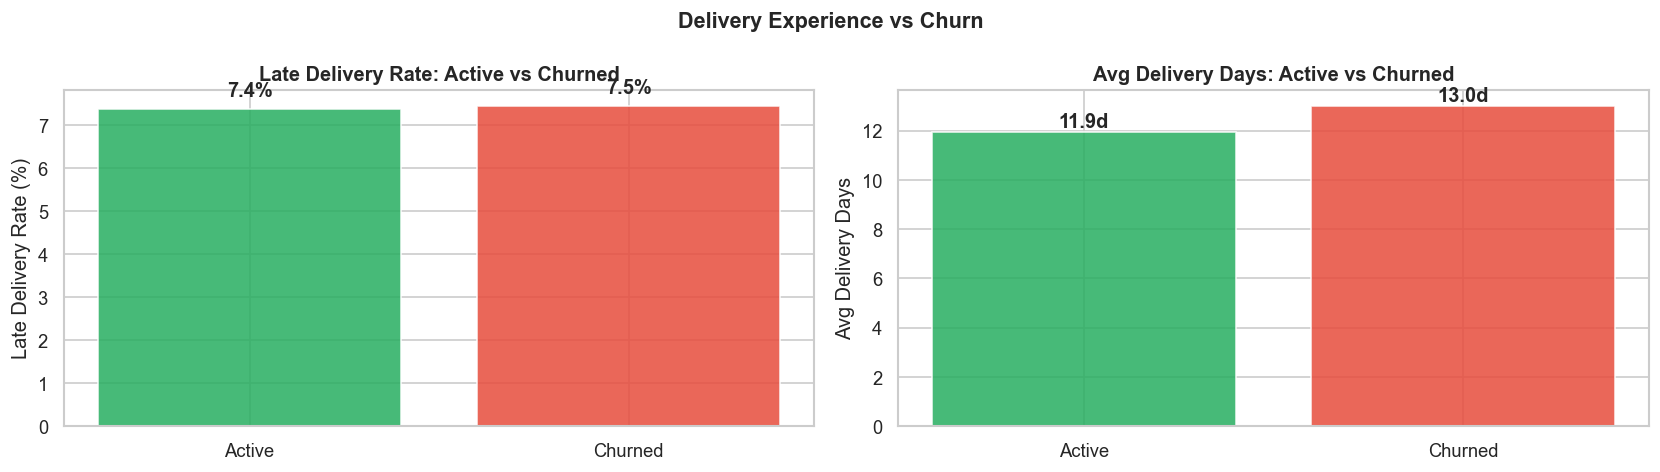

In [8]:
df_obs['delivery_days'] = (
    df_obs['order_delivered_customer_date'] - df_obs['order_purchase_timestamp']
).dt.days.clip(lower=0)

df_obs['delay_days'] = (
    df_obs['order_delivered_customer_date'] - df_obs['order_estimated_delivery_date']
).dt.days

df_obs['is_late'] = (df_obs['delay_days'] > 0).astype(int)

delivery_feats = df_obs.groupby('customer_unique_id').agg(
    avg_delivery_days   = ('delivery_days', 'mean'),
    max_delivery_days   = ('delivery_days', 'max'),
    avg_delay_days      = ('delay_days',    'mean'),
    max_delay_days      = ('delay_days',    'max'),
    late_delivery_count = ('is_late',       'sum'),
    total_deliveries    = ('is_late',       'count'),
).reset_index()

delivery_feats['late_delivery_rate']      = delivery_feats['late_delivery_count'] / delivery_feats['total_deliveries']
delivery_feats['ever_had_late_delivery']  = (delivery_feats['late_delivery_count'] > 0).astype(int)
delivery_feats['always_on_time']          = (delivery_feats['late_delivery_count'] == 0).astype(int)

print("Delivery features created:")
print(delivery_feats.describe().round(3))

temp4 = delivery_feats.merge(churn_target[['customer_unique_id','is_churned']], on='customer_unique_id')
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

late_c = temp4.groupby('is_churned')['late_delivery_rate'].mean()
axes[0].bar(['Active','Churned'], late_c.values * 100,
            color=['#27ae60','#e74c3c'], edgecolor='white', alpha=0.85)
for i, v in enumerate(late_c.values):
    axes[0].text(i, v*100+0.3, f'{v*100:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Late Delivery Rate: Active vs Churned', fontweight='bold')
axes[0].set_ylabel('Late Delivery Rate (%)')

avg_d = temp4.groupby('is_churned')['avg_delivery_days'].mean()
axes[1].bar(['Active','Churned'], avg_d.values,
            color=['#27ae60','#e74c3c'], edgecolor='white', alpha=0.85)
for i, v in enumerate(avg_d.values):
    axes[1].text(i, v+0.2, f'{v:.1f}d', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Avg Delivery Days: Active vs Churned', fontweight='bold')
axes[1].set_ylabel('Avg Delivery Days')

plt.suptitle('Delivery Experience vs Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 8 — Geography & Product Category Features

Customer region distribution:
customer_region
Southeast      50874
South          10948
Northeast       7148
Center-West     4391
North           1431

Top 10 preferred categories:
preferred_category
bed_bath_table           7152
health_beauty            6139
sports_leisure           5961
computers_accessories    5236
furniture_decor          4965
housewares               4048
watches_gifts            3951
telephony                3309
toys                     3142
cool_stuff               3113


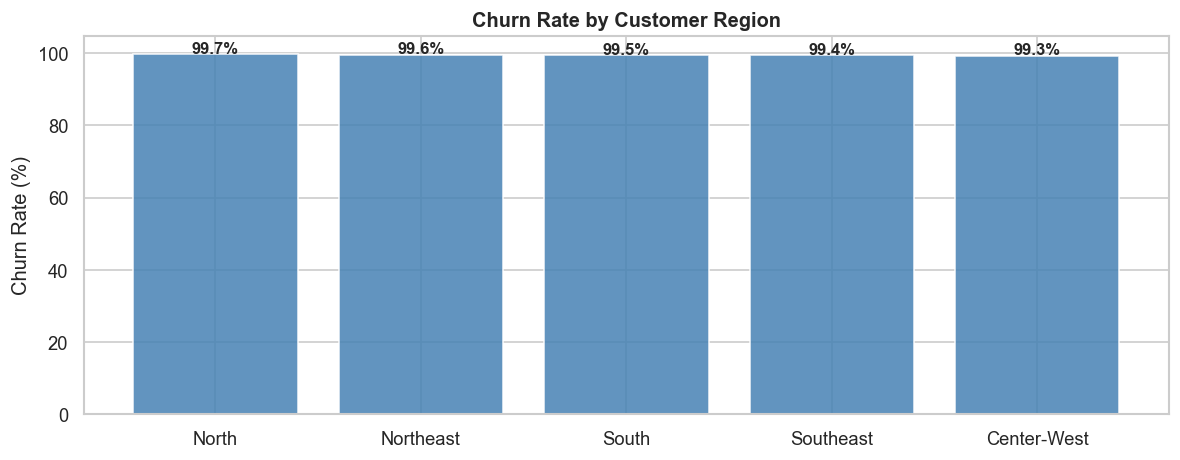

In [9]:
region_map = {
    'SP':'Southeast','RJ':'Southeast','MG':'Southeast','ES':'Southeast',
    'RS':'South',    'SC':'South',    'PR':'South',
    'BA':'Northeast','PE':'Northeast','CE':'Northeast','MA':'Northeast',
    'PB':'Northeast','RN':'Northeast','AL':'Northeast','SE':'Northeast','PI':'Northeast',
    'PA':'North',    'AM':'North',    'RO':'North',    'AC':'North',
    'AP':'North',    'RR':'North',    'TO':'North',
    'GO':'Center-West','MT':'Center-West','MS':'Center-West','DF':'Center-West'
}

geo_feats = (
    df_obs.groupby('customer_unique_id')
    .agg(
        customer_state  = ('customer_state', lambda x: x.mode()[0]),
        same_state_rate = ('customer_state',
                           lambda x: (x == df_obs.loc[x.index, 'seller_state']).mean()),
    )
    .reset_index()
)
geo_feats['customer_region'] = geo_feats['customer_state'].map(region_map).fillna('Other')

# Preferred product category
cat_feats = (
    df_obs.groupby('customer_unique_id')['product_category_name_english']
    .agg(lambda x: x.mode()[0] if x.notna().any() else 'unknown')
    .reset_index()
    .rename(columns={'product_category_name_english': 'preferred_category'})
)

# Product price features
product_feats = df_obs.groupby('customer_unique_id').agg(
    avg_product_price = ('price', 'mean'),
    max_product_price = ('price', 'max'),
).reset_index()
product_feats['log_avg_price'] = np.log1p(product_feats['avg_product_price'])

print("Customer region distribution:")
print(geo_feats['customer_region'].value_counts().to_string())
print("\nTop 10 preferred categories:")
print(cat_feats['preferred_category'].value_counts().head(10).to_string())

temp5 = geo_feats.merge(churn_target[['customer_unique_id','is_churned']], on='customer_unique_id')
region_churn = temp5.groupby('customer_region')['is_churned'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(region_churn.index, region_churn.values * 100,
       color='steelblue', edgecolor='white', alpha=0.85)
for i, (idx, v) in enumerate(region_churn.items()):
    ax.text(i, v*100+0.3, f'{v*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Churn Rate by Customer Region', fontsize=12, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

## Step 9 — Seller Quality Exposure

Seller quality features:
       avg_seller_review_experienced  avg_seller_ontime_experienced  \
count                      74792.000                      74792.000   
mean                           4.058                          0.929   
std                            0.358                          0.063   
min                            1.000                          0.000   
25%                            3.907                          0.908   
50%                            4.084                          0.941   
75%                            4.263                          0.961   
max                            5.000                          1.000   

       min_seller_review_experienced  num_unique_sellers  had_bad_seller  
count                      74792.000           74792.000       74792.000  
mean                           4.052               1.036           0.066  
std                            0.365               0.211           0.248  
min                            1.00

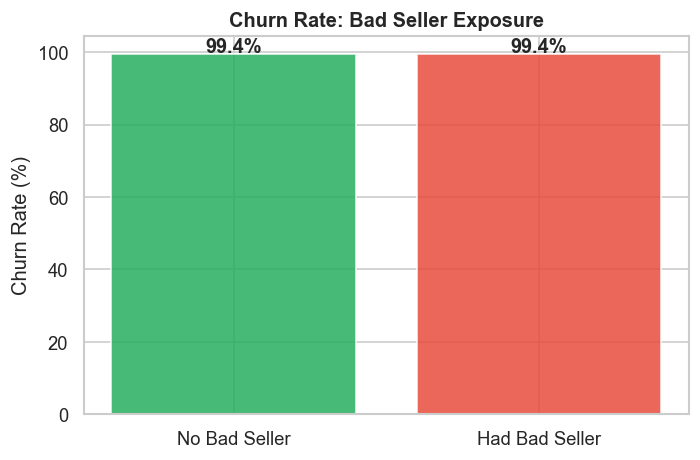

In [10]:
seller_rep = df_obs.groupby('seller_id').agg(
    seller_avg_review   = ('review_score',  'mean'),
    seller_on_time_rate = ('is_late',       lambda x: 1 - x.mean()),
    seller_avg_delivery = ('delivery_days', 'mean'),
    seller_order_count  = ('order_id',      'nunique'),
).reset_index()

df_obs_with_seller = df_obs.merge(seller_rep, on='seller_id', how='left')

seller_feats = df_obs_with_seller.groupby('customer_unique_id').agg(
    avg_seller_review_experienced = ('seller_avg_review',   'mean'),
    avg_seller_ontime_experienced = ('seller_on_time_rate', 'mean'),
    min_seller_review_experienced = ('seller_avg_review',   'min'),
    num_unique_sellers            = ('seller_id',           'nunique'),
).reset_index()

seller_feats['had_bad_seller'] = (seller_feats['min_seller_review_experienced'] < 3.5).astype(int)

print("Seller quality features:")
print(seller_feats.describe().round(3))

temp6 = seller_feats.merge(churn_target[['customer_unique_id','is_churned']], on='customer_unique_id')
bad_sc = temp6.groupby('had_bad_seller')['is_churned'].mean()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['No Bad Seller', 'Had Bad Seller'], bad_sc.values * 100,
       color=['#27ae60','#e74c3c'], edgecolor='white', alpha=0.85)
for i, v in enumerate(bad_sc.values):
    ax.text(i, v*100+0.5, f'{v*100:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Churn Rate: Bad Seller Exposure', fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

## Step 10 — Assemble, Validate & Save

Merge all feature groups into a single customer-level table and verify there are no unexpected nulls.

In [11]:
# ── Start from churn target (valid customers only) ────────────────────────────
customer_df = churn_target[['customer_unique_id', 'is_churned']].copy()

feature_tables = [
    (rfm,              'RFM'),
    (behavioral,       'Behavioral'),
    (payment_feats,    'Payment'),
    (review_feats,     'Review'),
    (delivery_feats,   'Delivery'),
    (geo_feats,        'Geography'),
    (cat_feats,        'Category'),
    (product_feats,    'Product'),
    (seller_feats,     'Seller'),
]

for table, name in feature_tables:
    before = len(customer_df.columns)
    customer_df = customer_df.merge(table, on='customer_unique_id', how='left')
    added = len(customer_df.columns) - before
    print(f"  {name:15s}: +{added:2d} columns → total {len(customer_df.columns)}")

print(f"\nFinal shape: {customer_df.shape[0]:,} customers × {customer_df.shape[1]} features")

# ── Null validation ───────────────────────────────────────────────────────────
nulls = customer_df.isnull().sum()
null_cols = nulls[nulls > 0].sort_values(ascending=False)
print(f"\nColumns with nulls: {len(null_cols)}")
if len(null_cols) > 0:
    print(null_cols.to_frame('null_count').assign(
        null_pct=lambda x: (x['null_count'] / len(customer_df) * 100).round(1)
    ).to_string())
else:
    print("  ✅ No nulls — dataset is clean!")

  RFM            : + 9 columns → total 11
  Behavioral     : +12 columns → total 23
  Payment        : +13 columns → total 36
  Review         : + 9 columns → total 45
  Delivery       : + 9 columns → total 54
  Geography      : + 3 columns → total 57
  Category       : + 1 columns → total 58
  Product        : + 3 columns → total 61
  Seller         : + 5 columns → total 66

Final shape: 74,792 customers × 66 features

Columns with nulls: 0
  ✅ No nulls — dataset is clean!


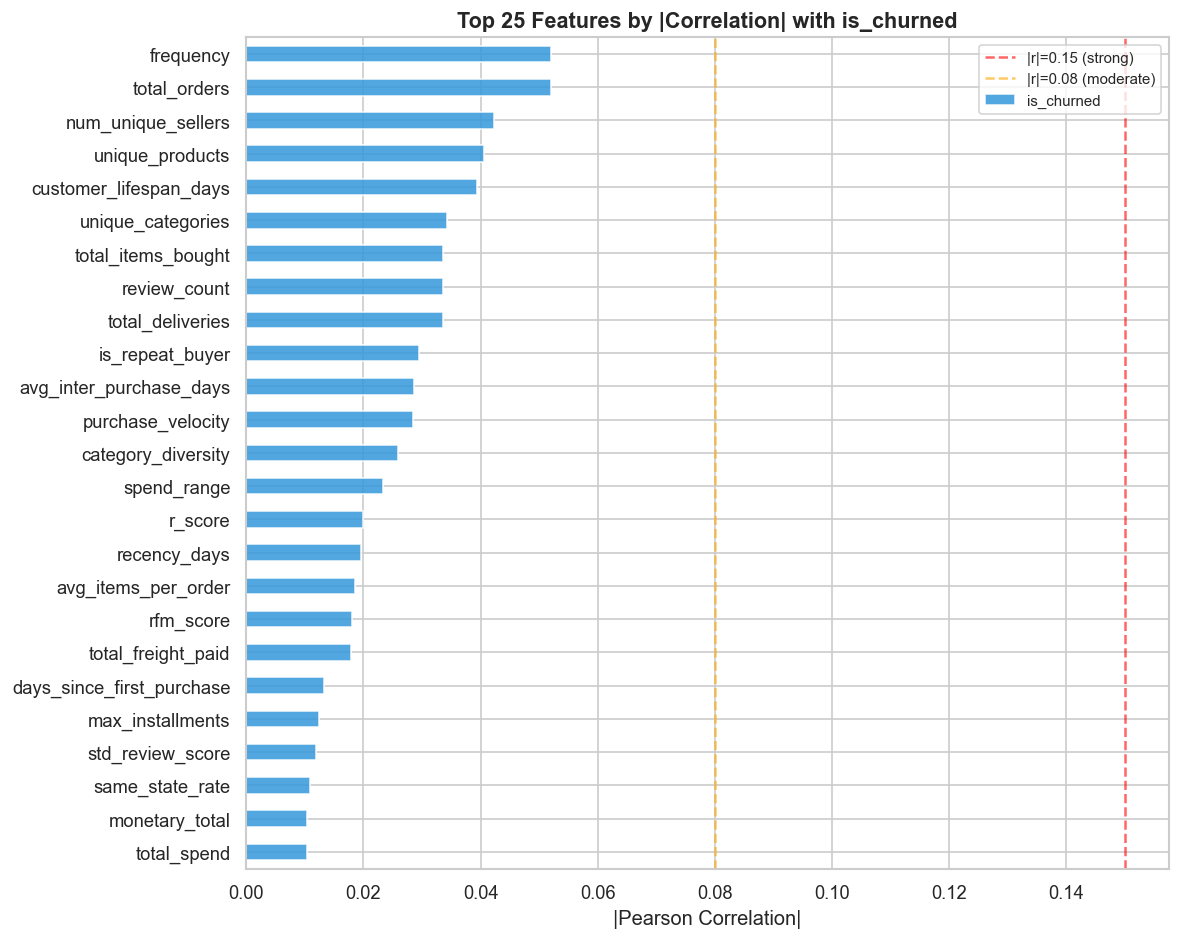


Top 15 features by |correlation| with is_churned:
frequency                  0.0521
total_orders               0.0521
num_unique_sellers         0.0423
unique_products            0.0406
customer_lifespan_days     0.0394
unique_categories          0.0342
total_items_bought         0.0335
review_count               0.0335
total_deliveries           0.0335
is_repeat_buyer            0.0294
avg_inter_purchase_days    0.0286
purchase_velocity          0.0285
category_diversity         0.0259
spend_range                0.0234
r_score                    0.0199


In [12]:
# ── Correlation with churn target ─────────────────────────────────────────────
numeric_cols = [
    c for c in customer_df.select_dtypes(include=[np.number]).columns
    if c != 'is_churned'
]

corr_target = (
    customer_df[numeric_cols + ['is_churned']]
    .corr()['is_churned']
    .drop('is_churned')
    .abs()
    .sort_values(ascending=False)
    .head(25)
)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v > 0.15 else '#f39c12' if v > 0.08 else '#3498db'
          for v in corr_target.values]
corr_target[::-1].plot(kind='barh', ax=ax, color=colors[::-1], edgecolor='white', alpha=0.85)
ax.set_title('Top 25 Features by |Correlation| with is_churned',
             fontsize=13, fontweight='bold')
ax.set_xlabel('|Pearson Correlation|')
ax.axvline(0.15, color='red',    linestyle='--', alpha=0.6, label='|r|=0.15 (strong)')
ax.axvline(0.08, color='orange', linestyle='--', alpha=0.6, label='|r|=0.08 (moderate)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 15 features by |correlation| with is_churned:")
print(corr_target.head(15).round(4).to_string())

In [13]:
# ── Feature inventory ─────────────────────────────────────────────────────────
feature_groups = {
    'RFM':        ['recency_days','frequency','monetary_total','monetary_avg_order',
                   'r_score','f_score','m_score','rfm_score','rfm_segment'],
    'Behavioral': ['total_orders','total_items_bought','avg_items_per_order',
                   'unique_categories','unique_products','customer_lifespan_days',
                   'days_since_first_purchase','purchase_velocity',
                   'avg_inter_purchase_days','is_repeat_buyer',
                   'weekend_ratio','category_diversity'],
    'Payment':    ['total_spend','avg_order_value','max_order_value',
                   'total_freight_paid','avg_installments',
                   'freight_to_spend_ratio','log_total_spend',
                   'log_avg_order_val','preferred_payment_type'],
    'Review':     ['avg_review_score','min_review_score','max_review_score',
                   'review_count','bad_review_count','bad_review_rate',
                   'had_very_bad_experience','consistently_satisfied'],
    'Delivery':   ['avg_delivery_days','max_delivery_days','avg_delay_days',
                   'late_delivery_rate','ever_had_late_delivery','always_on_time'],
    'Geography':  ['customer_state','customer_region','same_state_rate'],
    'Product':    ['preferred_category','avg_product_price','log_avg_price'],
    'Seller':     ['avg_seller_review_experienced','avg_seller_ontime_experienced',
                   'num_unique_sellers','had_bad_seller'],
    'Target':     ['is_churned'],
}

total_features = 0
print('\n' + '═'*58)
print('  CHURN PREDICTION FEATURE INVENTORY (v2)')
print('═'*58)
for group, cols in feature_groups.items():
    existing = [c for c in cols if c in customer_df.columns]
    if group != 'Target': total_features += len(existing)
    print(f"  {group:12s} ({len(existing):2d}): {existing}")
print('═'*58)
print(f"  Total features : {total_features}  |  Target: is_churned")
print(f"  Total customers: {len(customer_df):,}")
print(f"  Churn rate     : {customer_df['is_churned'].mean()*100:.1f}%")
print('═'*58)

# ── Save ──────────────────────────────────────────────────────────────────────
customer_df.to_csv('olist_churn_features.csv', index=False)

print(f"\n✅ Saved: olist_churn_features.csv")
print(f"   Shape: {customer_df.shape[0]:,} rows × {customer_df.shape[1]} columns")
print()
print('📌 Next step: Preprocessing notebook')
print('   → Encode: rfm_segment (label), customer_region, preferred_category, preferred_payment_type (target encode or one-hot)')
print('   → Drop: customer_state (use customer_region instead)')
print('   → Split: train/test stratified on is_churned')
print('   → Imbalance: use class_weight="balanced" in tree models, or SMOTE on training fold only')
print('   → Scale: StandardScaler or RobustScaler on numeric columns')


══════════════════════════════════════════════════════════
  CHURN PREDICTION FEATURE INVENTORY (v2)
══════════════════════════════════════════════════════════
  RFM          ( 9): ['recency_days', 'frequency', 'monetary_total', 'monetary_avg_order', 'r_score', 'f_score', 'm_score', 'rfm_score', 'rfm_segment']
  Behavioral   (12): ['total_orders', 'total_items_bought', 'avg_items_per_order', 'unique_categories', 'unique_products', 'customer_lifespan_days', 'days_since_first_purchase', 'purchase_velocity', 'avg_inter_purchase_days', 'is_repeat_buyer', 'weekend_ratio', 'category_diversity']
  Payment      ( 9): ['total_spend', 'avg_order_value', 'max_order_value', 'total_freight_paid', 'avg_installments', 'freight_to_spend_ratio', 'log_total_spend', 'log_avg_order_val', 'preferred_payment_type']
  Review       ( 8): ['avg_review_score', 'min_review_score', 'max_review_score', 'review_count', 'bad_review_count', 'bad_review_rate', 'had_very_bad_experience', 'consistently_satisfied']
  De